# TextMamba3D — A100 Full Training Pipeline (v4)

**Target:** Single A100 40GB (Colab)
**Architecture:** v4 — MultiScalePixelTextAttention (stages 1,2,3) + Unfreeze BERT last 2 layers
**Goal:** Text guidance contribution > vision-only baseline (v3: 88.15% vs 88.51%)

v4 changes vs v3:
- Fusion: bottleneck-only CrossAttention → multi-scale at stages 1,2,3 (4K+512+64 tokens)
- Text encoder: PubMedBERT last 2 layers unfrozen for task adaptation
- Stage 0 (32K tokens) excluded from cross-attention (VRAM constraint)
- Trainable params: ~38M (vs 24M in v3)
- PyTorch 2.6 `weights_only=False` fix applied

**Training config:**
- weight_decay: 0.01
- contrastive_weight: 0.0 (isolate fusion variable first)
- deep_supervision weights: [0.2, 0.1, 0.05]
- unfreeze_text_layers: 2

## 1. Environment Setup

In [4]:
# NOTE: If using VS Code Colab plugin, run this cell in Colab web UI first
# After mounting once, Drive stays available for the entire runtime session
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Cached to Drive: first run compiles mamba-ssm (~5min), subsequent runs use cached wheels (~30s)
!nvidia-smi
!pip install -q --cache-dir=/content/drive/MyDrive/pip_cache mamba-ssm causal-conv1d transformers nibabel tensorboard pyyaml tqdm

Thu Mar 12 10:09:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             46W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

## 2. Setup Working Directory & Prepare Data

Clone the TextMamba3D repo (first run only), then extract training data from Drive.

**Prerequisites:** Upload `TextBraTS_data.zip` to Google Drive (`My Drive/TextMamba3D/`).

In [6]:
import os, shutil

REPO_DIR = '/content/TextMamba3D'
DRIVE_BASE = '/content/drive/MyDrive/TextMamba3D'

# Deploy code from Drive (VS Code plugin only syncs notebook, not source files)
if not os.path.exists(REPO_DIR):
    src = os.path.join(DRIVE_BASE, 'TextMamba3D_code')
    if os.path.exists(src):
        shutil.copytree(src, REPO_DIR)
        print(f'Copied code from {src}')
    else:
        print(f'ERROR: {src} not found on Drive')
else:
    print(f'Repo already exists at {REPO_DIR}')

os.chdir(REPO_DIR)
print(f'Working directory: {os.getcwd()}')
!ls -la

Copied code from /content/drive/MyDrive/TextMamba3D/TextMamba3D_code
Working directory: /content/TextMamba3D
total 96
drwx------ 7 root root  4096 Mar  7 12:20 .
drwxr-xr-x 1 root root  4096 Mar 12 10:10 ..
drwx------ 2 root root  4096 Mar  7 12:21 configs
drwx------ 2 root root  4096 Mar  7 12:22 data
-rw------- 1 root root 10375 Mar  7 12:20 evaluate_full.py
-rw------- 1 root root  7910 Mar  7 12:20 evaluate.py
-rw------- 1 root root 14296 Mar  7 12:20 inference.py
drwx------ 2 root root  4096 Mar  7 12:21 losses
drwx------ 2 root root  4096 Mar  7 12:21 models
-rw------- 1 root root  3371 Mar  7 12:21 preprocess_data.py
-rw------- 1 root root  5360 Mar  7 12:20 smoke_test.py
-rw------- 1 root root 19878 Mar  7 12:20 train.py
drwx------ 2 root root  4096 Mar  7 12:21 utils


In [7]:
import pathlib, os

os.chdir(REPO_DIR)
print("=" * 60)
print("v4 Patch: Multi-Scale Fusion + Unfreeze BERT + Bug Fixes")
print("=" * 60)

# --- 0. Ensure MultiScalePixelTextAttention exists in fusion.py ---
fusion_path = pathlib.Path("models/fusion.py")
fusion_text = fusion_path.read_text()
if "MultiScalePixelTextAttention" not in fusion_text:
    fusion_path.write_text(fusion_text + '''


class MultiScalePixelTextAttention(nn.Module):
    """Apply PixelTextCrossAttention at multiple encoder stages."""

    def __init__(self, stage_dims: list[int], text_dim: int, num_heads: int = 4):
        super().__init__()
        self.attns = nn.ModuleList([
            PixelTextCrossAttention(img_dim=dim, text_dim=text_dim, num_heads=num_heads)
            for dim in stage_dims
        ])

    def forward(
        self,
        img_features: list[torch.Tensor],
        text_features: torch.Tensor,
        attention_mask: torch.Tensor | None = None,
    ) -> list[torch.Tensor]:
        return [
            attn(img, text_features, attention_mask)
            for attn, img in zip(self.attns, img_features)
        ]
''')
    print("[0/6] Added MultiScalePixelTextAttention to fusion.py")
else:
    print("[0/6] fusion.py already has MultiScalePixelTextAttention")

# --- 1. models/textmamba3d.py: bottleneck-only -> multi-scale fusion ---
pathlib.Path("models/textmamba3d.py").write_text('''# models/textmamba3d.py
"""Text-guided 3D medical image segmentation with Mamba architecture."""

from typing import Optional

import torch
import torch.nn as nn

from .decoder_3d import MambaDecoder3D
from .encoder_3d import MambaEncoder3D
from .fusion import MultiScalePixelTextAttention
from .text_encoder import TextMambaEncoder


class TextMamba3D(nn.Module):
    """Text-guided 3D medical image segmentation model using Mamba architecture."""

    def __init__(
        self,
        img_size: tuple[int, int, int] = (96, 96, 96),
        in_channels: int = 4,
        out_channels: int = 4,
        embed_dim: int = 96,
        depths: list[int] = [2, 2, 2, 2],
        patch_size: tuple[int, int, int] = (4, 4, 4),
        text_embed_dim: int = 256,
        text_max_len: int = 256,
        text_depth: int = 4,
        d_state: int = 16,
        dropout: float = 0.0,
        use_pretrained_text: bool = True,
        unfreeze_text_layers: int = 0,
        use_checkpoint: bool = False,
        text_model_path: str | None = None,
        deep_supervision: bool = False,
    ) -> None:
        super().__init__()

        self.text_embed_dim = text_embed_dim
        self.text_max_len = text_max_len
        bottleneck_dim = embed_dim * (2 ** (len(depths) - 1))

        self.img_encoder = MambaEncoder3D(
            img_size=img_size,
            in_channels=in_channels,
            embed_dim=embed_dim,
            depths=depths,
            patch_size=patch_size,
            d_state=d_state,
            dropout=dropout,
            use_checkpoint=use_checkpoint,
        )

        self.text_encoder = TextMambaEncoder(
            embed_dim=text_embed_dim,
            max_len=text_max_len,
            depth=text_depth,
            d_state=d_state,
            dropout=dropout,
            use_pretrained=use_pretrained_text,
            unfreeze_last_n=unfreeze_text_layers,
            model_path=text_model_path,
        )

        # Multi-scale cross-attention: text guides skip connections at stages 1,2,3
        # Stage 0 excluded (32K tokens too expensive for cross-attention)
        stage_dims = [embed_dim * (2 ** i) for i in range(1, len(depths))]
        self.multi_scale_attn = MultiScalePixelTextAttention(
            stage_dims=stage_dims,     # [96, 192, 384] for embed_dim=48
            text_dim=text_embed_dim,   # 256
            num_heads=4,               # head_dim varies per stage
        )

        self.decoder = MambaDecoder3D(
            img_size=img_size,
            patch_size=patch_size,
            out_channels=out_channels,
            embed_dim=embed_dim,
            depths=depths,
            d_state=d_state,
            dropout=dropout,
            use_checkpoint=use_checkpoint,
            deep_supervision=deep_supervision,
        )

        self.img_proj = nn.Sequential(
            nn.Linear(bottleneck_dim, text_embed_dim),
            nn.LayerNorm(text_embed_dim),
        )

    def forward(
        self,
        img: torch.Tensor,
        text_ids: Optional[torch.Tensor] = None,
        attention_mask: Optional[torch.Tensor] = None,
        return_features: bool = False,
        use_text: bool = True,
    ) -> torch.Tensor | tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
        """
        Forward pass for text-guided 3D segmentation.

        Args:
            img: Input image tensor of shape [B, C, D, H, W]
            text_ids: Text token indices of shape [B, L], optional for inference
            attention_mask: [B, L] mask for text padding (1=valid, 0=pad)
            return_features: Whether to return features for contrastive loss
            use_text: Whether to use text guidance (False for text-free inference)

        Returns:
            Segmentation output [B, out_channels, D, H, W], and optionally
            (img_feat, text_feat) for contrastive loss
        """
        img_features = self.img_encoder(img)

        has_text = use_text and text_ids is not None
        if has_text:
            text_features = self.text_encoder(text_ids, attention_mask)
            # Multi-scale fusion: stages 1,2,3 get text cross-attention
            # Stage 0 stays raw (32K tokens, too expensive for cross-attention)
            fused = self.multi_scale_attn(
                img_features[1:], text_features, attention_mask
            )
            decoder_features = [img_features[0]] + fused
        else:
            # Bypass fusion entirely for text-free path
            decoder_features = img_features

        seg_output = self.decoder(decoder_features)

        if not return_features:
            return seg_output

        if has_text:
            # Contrastive: project fused bottleneck for alignment
            img_global = self.img_proj(decoder_features[-1].mean(dim=1))
            text_global = self.text_encoder.get_global_feature(text_features)
            return seg_output, img_global, text_global
        else:
            # No contrastive on text-free batches
            return seg_output, None, None

    def forward_without_text(self, img: torch.Tensor) -> torch.Tensor:
        """Convenience method for inference without text guidance."""
        return self.forward(img, text_ids=None, use_text=False)
''')
print("[1/6] textmamba3d.py -> v4 multi-scale fusion (stages 1,2,3)")

# --- 2. models/__init__.py (add MultiScalePixelTextAttention export) ---
pathlib.Path("models/__init__.py").write_text(
    "from .mamba_block import ("
    + chr(10) + "    MambaBlock, MambaLayer,"
    + chr(10) + "    BiMambaBlock, BiMambaLayer,"
    + chr(10) + "    CrossScanBiMamba3DBlock, CrossScanBiMamba3DLayer,"
    + chr(10) + ")"
    + chr(10) + "from .encoder_3d import PatchEmbed3D, MambaEncoder3D"
    + chr(10) + "from .text_encoder import TextMambaEncoder"
    + chr(10) + "from .fusion import PixelTextCrossAttention, MultiScalePixelTextAttention, FiLMLayer, MultiScaleFiLM, MambaFusion"
    + chr(10) + "from .decoder_3d import MambaDecoder3D"
    + chr(10) + "from .textmamba3d import TextMamba3D"
    + chr(10)
)
print("[2/6] __init__.py -> added MultiScalePixelTextAttention export")

# --- 3. configs/textbrats_a100.yaml (unfreeze_text_layers: 2) ---
pathlib.Path("configs/textbrats_a100.yaml").write_text(
    "# textbrats_a100.yaml - v4 multi-scale fusion + unfreeze BERT"
    + chr(10) + "# A100 40GB optimized"
    + chr(10) + ""
    + chr(10) + "data:"
    + chr(10) + '  data_dir: "./data/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData"'
    + chr(10) + '  dataset_type: "textbrats"'
    + chr(10) + "  patch_size: [128, 128, 128]"
    + chr(10) + "  batch_size: 4"
    + chr(10) + "  num_workers: 4"
    + chr(10) + "  train_ratio: 0.596"
    + chr(10) + "  val_ratio: 0.149"
    + chr(10) + ""
    + chr(10) + "model:"
    + chr(10) + "  img_size: [128, 128, 128]"
    + chr(10) + "  in_channels: 4"
    + chr(10) + "  out_channels: 4"
    + chr(10) + "  embed_dim: 48"
    + chr(10) + "  depths: [2, 2, 2, 2]"
    + chr(10) + "  dropout: 0.1"
    + chr(10) + "  text_embed_dim: 256"
    + chr(10) + "  text_max_len: 256"
    + chr(10) + "  use_pretrained_text: true"
    + chr(10) + "  unfreeze_text_layers: 2        # Unfreeze last 2 BERT layers"
    + chr(10) + "  text_model_path: null"
    + chr(10) + ""
    + chr(10) + "loss:"
    + chr(10) + "  dice_weight: 1.0"
    + chr(10) + "  ce_weight: 1.0"
    + chr(10) + "  edge_weight: 1.0"
    + chr(10) + "  contrastive_weight: 0.0"
    + chr(10) + "  temperature: 0.07"
    + chr(10) + "  class_weights: [0.25, 3.0, 1.0, 4.0]"
    + chr(10) + ""
    + chr(10) + "augmentation:"
    + chr(10) + "  use_elastic: true"
    + chr(10) + "  use_modality_dropout: true"
    + chr(10) + ""
    + chr(10) + "training:"
    + chr(10) + "  epochs: 200"
    + chr(10) + "  lr: 0.0001"
    + chr(10) + "  weight_decay: 0.01"
    + chr(10) + "  warmup_epochs: 10"
    + chr(10) + "  patience: 40"
    + chr(10) + "  gradient_accumulation: 1"
    + chr(10) + "  gradient_checkpointing: true"
    + chr(10) + "  deep_supervision: true"
    + chr(10) + "  ds_weights: [0.2, 0.1, 0.05]"
    + chr(10) + "  use_amp: true"
    + chr(10) + "  no_text_ratio: 0.15"
    + chr(10) + "  gradient_clip_norm: 1.0"
    + chr(10) + ""
    + chr(10) + "eval:"
    + chr(10) + '  metrics: ["dice", "hd95"]'
    + chr(10) + "  sliding_window: true"
    + chr(10) + "  sw_overlap: 0.5"
    + chr(10) + "  sw_batch_size: 2"
    + chr(10) + ""
    + chr(10) + "experiment:"
    + chr(10) + '  name: "TextMamba3D_A100_v4_multiscale"'
    + chr(10) + '  description: "v4: multi-scale text fusion (stages 1,2,3) + unfreeze BERT last 2 layers"'
    + chr(10)
)
print("[3/6] textbrats_a100.yaml -> unfreeze_text_layers: 2, v4 experiment name")

# --- 4-6. PyTorch 2.6 weights_only=False fix ---
patched = []
for fname in ["evaluate_full.py", "train.py", "inference.py"]:
    p = pathlib.Path(fname)
    lines = p.read_text().splitlines(True)
    new_lines = []
    changed = False
    for line in lines:
        if "torch.load(" in line and "weights_only" not in line and ")" in line:
            idx = line.rindex(")")
            line = line[:idx] + ", weights_only=False" + line[idx:]
            changed = True
        new_lines.append(line)
    if changed:
        p.write_text("".join(new_lines))
        patched.append(fname)
if patched:
    print("[4-6/6] weights_only=False fix: " + ", ".join(patched))
else:
    print("[4-6/6] weights_only already set in all files")

print()
print("All v4 patches applied successfully!")
print("Expected: ~38M trainable params (vs 24M in v3)")
print("Key changes:")
print("  - Multi-scale text fusion at encoder stages 1,2,3")
print("  - PubMedBERT last 2 layers unfrozen")
print("  - PyTorch 2.6 weights_only compatibility")

v4 Patch: Multi-Scale Fusion + Unfreeze BERT + Bug Fixes
[0/6] fusion.py already has MultiScalePixelTextAttention
[1/6] textmamba3d.py -> v4 multi-scale fusion (stages 1,2,3)
[2/6] __init__.py -> added MultiScalePixelTextAttention export
[3/6] textbrats_a100.yaml -> unfreeze_text_layers: 2, v4 experiment name
[4-6/6] weights_only=False fix: evaluate_full.py, train.py

All v4 patches applied successfully!
Expected: ~38M trainable params (vs 24M in v3)
Key changes:
  - Multi-scale text fusion at encoder stages 1,2,3
  - PubMedBERT last 2 layers unfrozen
  - PyTorch 2.6 weights_only compatibility


In [8]:
import zipfile

# Extract BraTS data from Drive to local /content for fast I/O
DATA_ZIP = os.path.join(DRIVE_BASE, "TextBraTS_data.zip")
DATA_DIR = os.path.join(REPO_DIR, "data/BraTS2020/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData")

if not os.path.exists(DATA_DIR):
    os.makedirs(os.path.dirname(DATA_DIR), exist_ok=True)
    if os.path.exists(DATA_ZIP):
        print(f"Extracting {DATA_ZIP} ...")
        with zipfile.ZipFile(DATA_ZIP, 'r') as zf:
            zf.extractall(os.path.dirname(DATA_DIR))
        print(f"Done. Cases found: {len(os.listdir(DATA_DIR))}")
    else:
        print(f"ERROR: Data zip not found at {DATA_ZIP}")
        print("Upload TextBraTS_data.zip to Drive/TextMamba3D/")
else:
    print(f"Data already extracted. Cases: {len(os.listdir(DATA_DIR))}")

Extracting /content/drive/MyDrive/TextMamba3D/TextBraTS_data.zip ...
Done. Cases found: 371


## 3. Smoke Test (Quick Sanity Check)

Verify everything works: load model, check param count, run 1 epoch on 10 samples, confirm VRAM usage.

In [9]:
# Smoke test: 10 samples, vision-only (quick VRAM check for v4 architecture)
!python train.py --config configs/textbrats_a100.yaml --max-samples 10 --no-text-ratio 1.0 --grad-accum 1 --max-epochs 30

# Check peak VRAM (subprocess has separate CUDA context)
!nvidia-smi --query-gpu=memory.used --format=csv,noheader,nounits
print("(Peak VRAM reported by nvidia-smi after smoke test)")

2026-03-12 10:13:40.886294: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 10:13:40.904426: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773310420.926957    2770 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773310420.934373    2770 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773310420.953875    2770 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 4. Training

**Strategy:** Single training run with `no_text_ratio=0.15` (85% with-text, 15% without).
Evaluation compares both modes from the same checkpoint — no separate vision-only run needed.

v4 architecture ensures clean comparison:
- **with-text:** MultiScalePixelTextAttention fuses image features at stages 1,2,3 with text
- **no-text:** fusion completely bypassed, raw encoder features pass to decoder

In [10]:
# Auto-save checkpoints to Drive every N epochs
DRIVE_CKPT = os.path.join(DRIVE_BASE, "checkpoints")
os.makedirs(DRIVE_CKPT, exist_ok=True)

def sync_checkpoints_to_drive():
    """Copy latest checkpoints to Drive for persistence."""
    import glob
    local_ckpt = os.path.join(REPO_DIR, "checkpoints")
    if not os.path.exists(local_ckpt):
        return
    for f in glob.glob(os.path.join(local_ckpt, "*.pth")):
        dst = os.path.join(DRIVE_CKPT, os.path.basename(f))
        shutil.copy2(f, dst)
    print(f"Synced checkpoints to {DRIVE_CKPT}")

print(f"Drive checkpoint dir: {DRIVE_CKPT}")

Drive checkpoint dir: /content/drive/MyDrive/TextMamba3D/checkpoints


### Training: v4 Multi-Scale Fusion + Unfreeze BERT

**v4 architecture:** MultiScalePixelTextAttention at stages 1,2,3 + PubMedBERT last 2 layers unfrozen.
85% batches use text (multi-scale cross-attention active), 15% without text (fusion bypassed).
Single run produces both with-text and no-text evaluation from same checkpoint.

**Note:** v4 checkpoint incompatible with v3 — must train from scratch.

In [11]:
os.chdir(REPO_DIR)
os.environ["DRIVE_CKPT_DIR"] = DRIVE_CKPT

# Clean previous checkpoints to avoid confusion
import glob
for f in glob.glob(os.path.join(REPO_DIR, "checkpoints/*.pth")):
    os.remove(f)

# v4 training: MultiScalePixelTextAttention at stages 1,2,3 + unfreeze BERT
# no_text_ratio=0.15: 85% with-text, 15% text-free (fusion bypassed)
!python train.py \
    --config configs/textbrats_a100.yaml \
    --no-text-ratio 0.15 \
    --grad-accum 1

# Sync and save
sync_checkpoints_to_drive()

best_ckpt = os.path.join(DRIVE_CKPT, "best_v4.pth")
local_best = os.path.join(REPO_DIR, "checkpoints/best.pth")
if os.path.exists(local_best):
    shutil.copy2(local_best, best_ckpt)
    print(f"Best checkpoint saved: {best_ckpt}")

2026-03-12 10:14:03.195506: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-12 10:14:03.213688: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773310443.235371    2922 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773310443.242493    2922 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773310443.260842    2922 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

## 5. Full-Volume Evaluation (Sliding Window)

Evaluate best checkpoint in both modes (with-text and no-text) using sliding window inference with Gaussian importance weighting.

In [12]:
os.chdir(REPO_DIR)

# Find best checkpoint
ckpt = os.path.join(REPO_DIR, "checkpoints/best.pth")
if not os.path.exists(ckpt):
    ckpt = os.path.join(DRIVE_CKPT, "best_v4.pth")

if os.path.exists(ckpt):
    # Evaluate WITH text guidance
    print("=" * 60)
    print("Evaluation: With Text (MultiScale fusion active)")
    print("=" * 60)
    !python evaluate_full.py \
        --config configs/textbrats_a100.yaml \
        --checkpoint "{ckpt}" \
        --split test \
        --use-text \
        --overlap 0.5

    print()

    # Evaluate WITHOUT text (fusion bypassed, pure vision)
    print("=" * 60)
    print("Evaluation: Without Text (fusion bypassed)")
    print("=" * 60)
    !python evaluate_full.py \
        --config configs/textbrats_a100.yaml \
        --checkpoint "{ckpt}" \
        --split test \
        --no-text \
        --overlap 0.5
else:
    print(f"Checkpoint not found. Train first.")

Evaluation: With Text (MultiScale fusion active)
Loading weights: 100% 199/199 [00:00<00:00, 992.05it/s, Materializing param=pooler.dense.weight]                                
BertModel LOAD REPORT from: microsoft/BiomedNLP-PubMedBERT-base-uncased-abstract-fulltext
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading 

## 6. Results Summary & Visualization

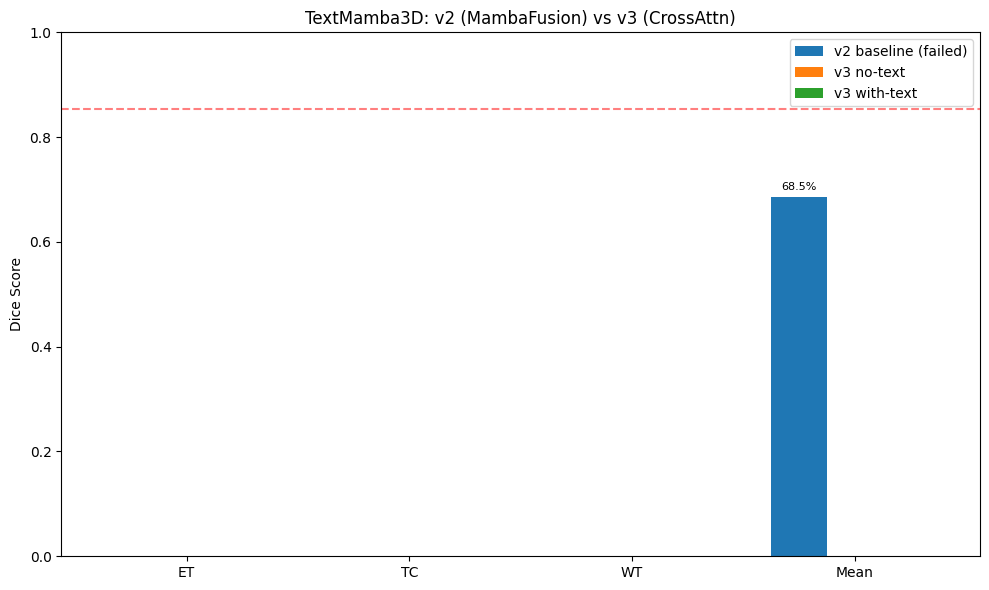

Fill in Dice values after evaluation!


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Fill in results after training complete
# Format: [ET, TC, WT, Mean]
results = {
    "v2 RTX4060 (MambaFusion+FiLM)": {
        "dice": [0.0, 0.0, 0.0, 0.6848],
        "label": "v2 baseline (failed)"
    },
    "v3 A100 no-text (bypass)": {
        "dice": [0.0, 0.0, 0.0, 0.0],  # FILL AFTER EVAL
        "label": "v3 no-text"
    },
    "v3 A100 with-text (CrossAttn)": {
        "dice": [0.0, 0.0, 0.0, 0.0],  # FILL AFTER EVAL
        "label": "v3 with-text"
    },
}

regions = ["ET", "TC", "WT", "Mean"]
x = np.arange(len(regions))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
for i, (name, data) in enumerate(results.items()):
    bars = ax.bar(x + i * width, data["dice"], width, label=data["label"])
    for bar, val in zip(bars, data["dice"]):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.01,
                    f'{val:.1%}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Dice Score')
ax.set_title('TextMamba3D: v2 (MambaFusion) vs v3 (CrossAttn)')
ax.set_xticks(x + width)
ax.set_xticklabels(regions)
ax.legend()
ax.set_ylim(0, 1.0)
ax.axhline(y=0.853, color='r', linestyle='--', alpha=0.5, label='SOTA (85.3%)')
plt.tight_layout()
plt.savefig("results_comparison.png", dpi=150)
plt.show()

print("Fill in Dice values after evaluation!")

## 7. TensorBoard (Optional)

In [14]:
%load_ext tensorboard
%tensorboard --logdir logs

<IPython.core.display.Javascript object>

## 8. Resume Training (After Colab Disconnect)

If Colab disconnects mid-training, run this cell to resume from the last checkpoint saved to Drive.